## **DataLab Cup 3: Reverse Image Caption**

**Team Name:** Team04

**Team Member:** 113065703 翁嘉妤、114501538 林言蓉、114062516 李子賢

### **I. Text Embedding Strategy**

在這次的競賽中，將文字轉為好的 Feature Vector 是重點。不同於 Lab 範例中使用 RNN 從頭訓練，我們選擇了 **Universal Sentence Encoder (USE)** 的預訓練模型來進行 Caption 的 Embedding。

我們發現相比於自己訓練的 RNN、LSTM，USE 對於顏色和形狀的語意理解更為精確。為了節省訓練時間，我們採用了 `precompute` 的策略，先將所有 Caption 轉成 `.npz` 檔儲存下來，這樣在 Training 階段的每個 Epoch 就不需要重複計算 Embedding，大幅提升訓練速度。

### **II. Data Processing & Augmentation**

- **Dataset Handling**

    原始資料集中，一張圖片對應多個 Caption。為了讓模型學得更好，我們不是只 Random 取一個，而是將所有 Caption 與圖片的 Pair 全部展開放入 Dataset，將訓練資料提高到 70000 筆。雖然這會導致同一個 Image 在一個 Epoch 中出現多次，但配合不同的 Caption 描述，搭配 Data Augmentation 反而能幫助 Generator 學習到更細緻的特徵。

- **Data Augmentation**

    為了避免 Overfitting，我們在 Data Pipeline 中加入了即時的 Augmentation。我們使用了 `tf.image.random_flip_left_right` 以及 `random_brightness` (max_delta=0.05)。我們有嘗試過調整 Hue，但發現這樣會破壞 Caption 中對顏色的描述，導致 Loss 難以收斂，因此最終只保留了幾何與亮度的變換。

### **III. Model Architecture**
經過多次實驗，我們捨棄了原本不穩定的 DCGAN，最終採用 **WGAN-GP** 搭配 **FiLM** 的架構。

* **Generator with FiLM:**
    - 這是我們模型最大的進步點。一般的做法是將 Text Embedding 與 Noise 直接 Concat，但我們實作了 **Feature-wise Linear Modulation (FiLM)**。
    
    - Text Embedding 會通過 Dense Layer 學習出一組 $\gamma$ 和 $\beta$，用來在每個 Upsampling Block 對 Feature Map 做 Affine Transformation。實驗證明，FiLM 比單純的 Concat 能更有效地控制花朵的細節特徵。

* **Discriminator & Loss Function:**
    
    - 我們使用 **WGAN-GP (Gradient Penalty)** 來取代 Weight Clipping。

    - 我們猜 Weight Clipping 容易讓 weight 集中在數值邊界，可能導致生出來的圖片很假。改用 Gradient Penalty ($\lambda=10$) 後，訓練曲線平滑許多。
    
    - Discriminator 部分我們採用了 Concat Conditioning，在最後判斷真假前，將 Text Embedding 複製並與圖片特徵結合，強迫 Discriminator 檢查圖片是否符合文字描述。

* **Hyper-parameters & Training Stability:**
    
    我們深刻體會到 GAN 的訓練就是在通靈，Generator 與 Discriminator 之間的強弱要維持完美的動態平衡。沒調好常常出現一方完全壓著另一方打的情況：

    1. **Discriminator 過強/過弱的問題 (n_critic)**: 
    
        起初我們發現如果 Discriminator 更新太快，Loss 會瞬間降到 0，導致 Generator 收不到有效的 Gradient 而造成 Gradient Vanishing；反之如果 Discriminator 太弱，Generator 就會開始偷懶。我們嘗試了 1:1 與 5:1 的比例，最後發現設定 n_critic=3（每訓練 1 次 G，訓練 3 次 D）能讓 Discriminator 保持領先但不會強到讓 Generator 絕望。

    2. **TTUR**:
    
        我們對兩者設定不同的學習率。給 Discriminator 較高的 $LR_D=2e-4$，Generator 則給較低 $LR_G=1e-4$，讓 Discriminator 能抓取假圖上的特徵，引導 Generator 收斂。

    3. **Normalization**: 
    
        我們發現 DCGAN 常用的 Batch Normalization 會導致訓練不穩，因此我們在 Generator 使用 Layer Norm，而 Discriminator 移除所有 Batch Norm 來符合 WGAN-GP 要求

### **IV. Experiments & Analysis**

- **Comparison of Models**

    1.  **DCGAN:**
        
        這是我們最早嘗試的 Baseline。但實驗結果很糟，很容易發生 Mode Collapse，後來就放棄了。

    2.  **Latent Diffusion Model (The High Scorer):**
        
        **我們在 Kaggle Leaderboard 上最高的 Private Score 其實是來自 Diffusion Model。**
        
        Diffusion 的強大生成的圖像在光影、背景與藝術感上完全輾壓 GAN，Diffusion 的訓練也相對穩定，不需要花太多時間調參就能得到不錯的結果。然而，我們最終決定在報告中聚焦於 GAN，原因有以下兩點：
        
        - **實作深度：** 
        
            Diffusion 雖然效果好，但光看每個時間點的 Loss 的變化難以解釋模型學到了什麼，且大部分的架構與訓練技巧都是沿用現成的論文，實作深度較淺。而我們在 WGAN-GP 上花了大量時間調參、改架構（FiLM, TTUR, Loss Design），對 GAN 的理解更深。GAN 的訓練過程讓我們真正理解了 Generator 與 Discriminator 的對抗機制。
        
        - **圖文控制：** 
        
            因為 Diffusion Model 在生成過程中引入了大量隨機性，導致對 Caption 的精確控制較為困難。我們發現 Diffusion 雖然 Loss 很低，生成的圖很自然，但在細節花朵的顏色、形狀上常常沒辦法符合文字敘述，可能是因為模型過於依賴圖像的結構，而忽略了文字描述中的細節要求，很難強迫模型學習文字與圖像的對應關係，而我們的 WGAN-GP 模型則能更好地根據 Caption 生成符合要求的圖像。

    3.  **WGAN-GP (Our Main Focus):**
    
        雖然在絕對的畫質與分數上稍微輸給 Diffusion，但它不僅訓練速度快、推論速度高，且在圖文一致性的控制上讓我們學到了最多 Deep Learning 的訓練技巧。

- **Inference Strategy (Candidate Selection)**

    為了彌補 GAN 在生成多樣性上的不足和進一步推升分數，我們用了 "Best-of-N" 的技巧。在 Testing 階段，對每個 Caption 生成 **4 張 ($k=4$)** 候選圖，利用訓練好的 Discriminator 當作評審對這 4 張圖打分，選出它覺得最好的那張，些微提升了我們的成績。

### **V. Generated Image**
下圖展示了我們用 WGAN-GP 和 Diffusion 在 Testing Data 上的生成結果。每一列是同一個 Caption，共 5 種不同的 Random Noise。

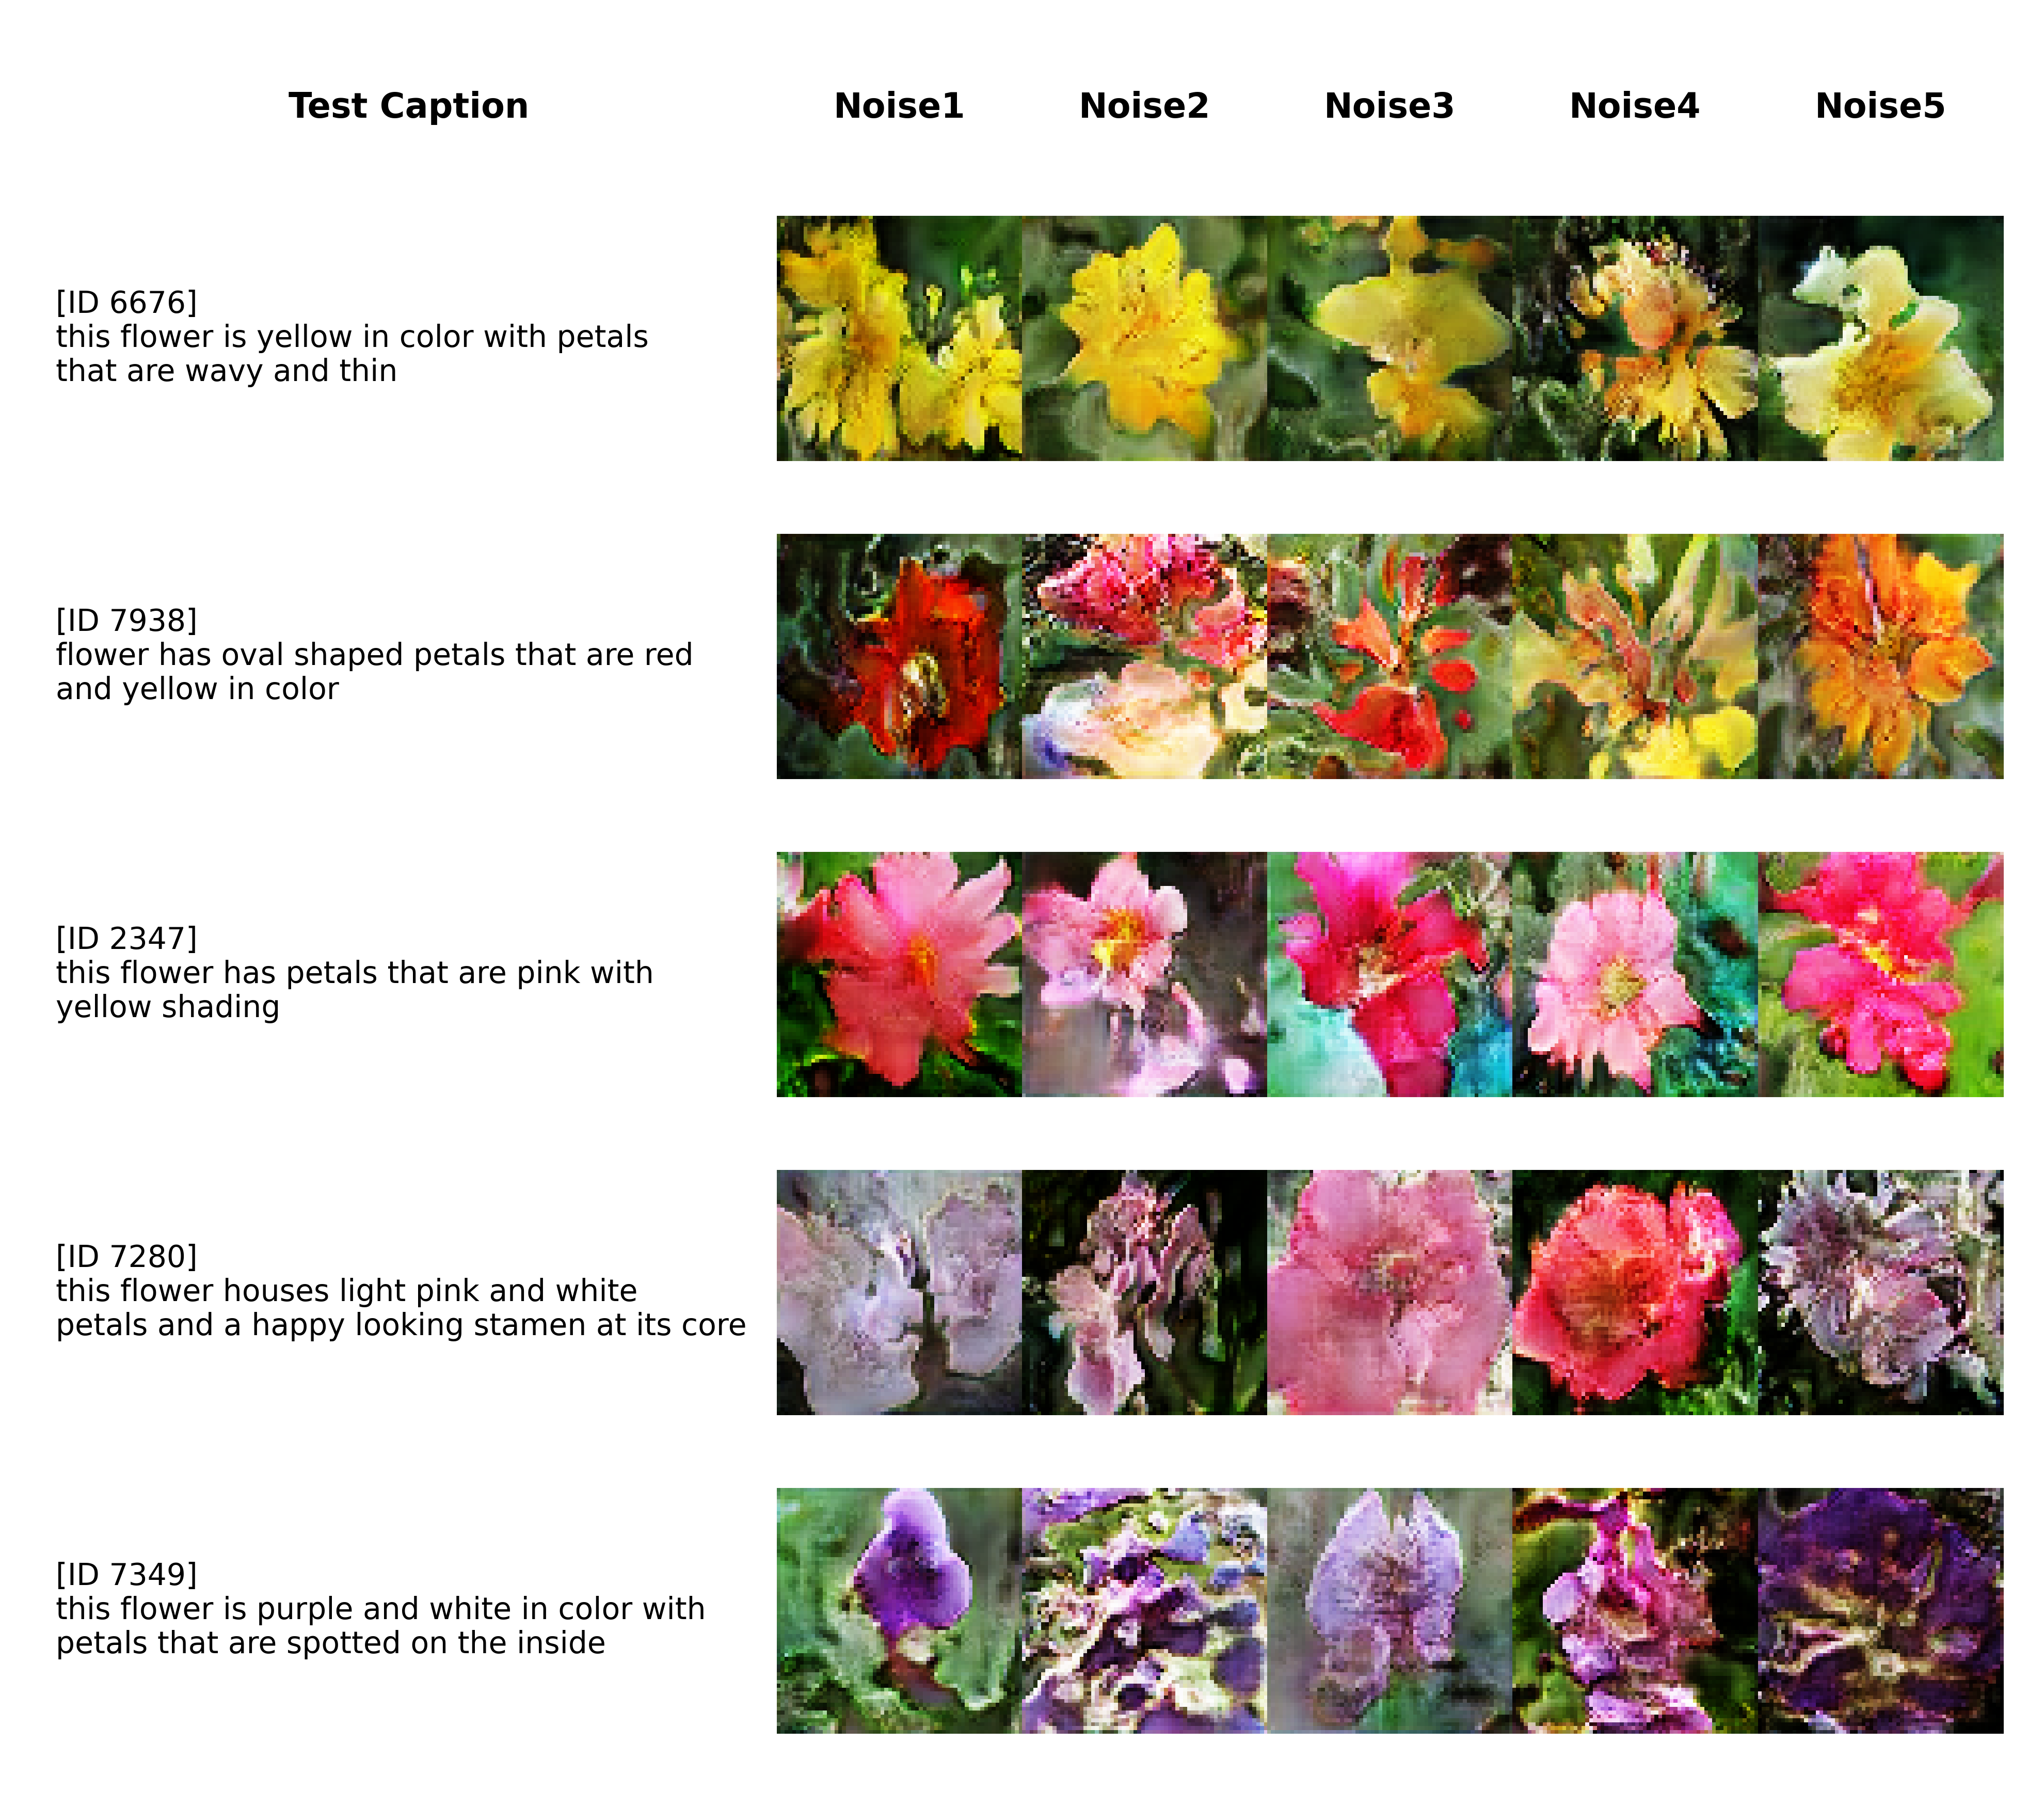

In [9]:
from IPython.display import Image
Image('./5captions_5noises.png')

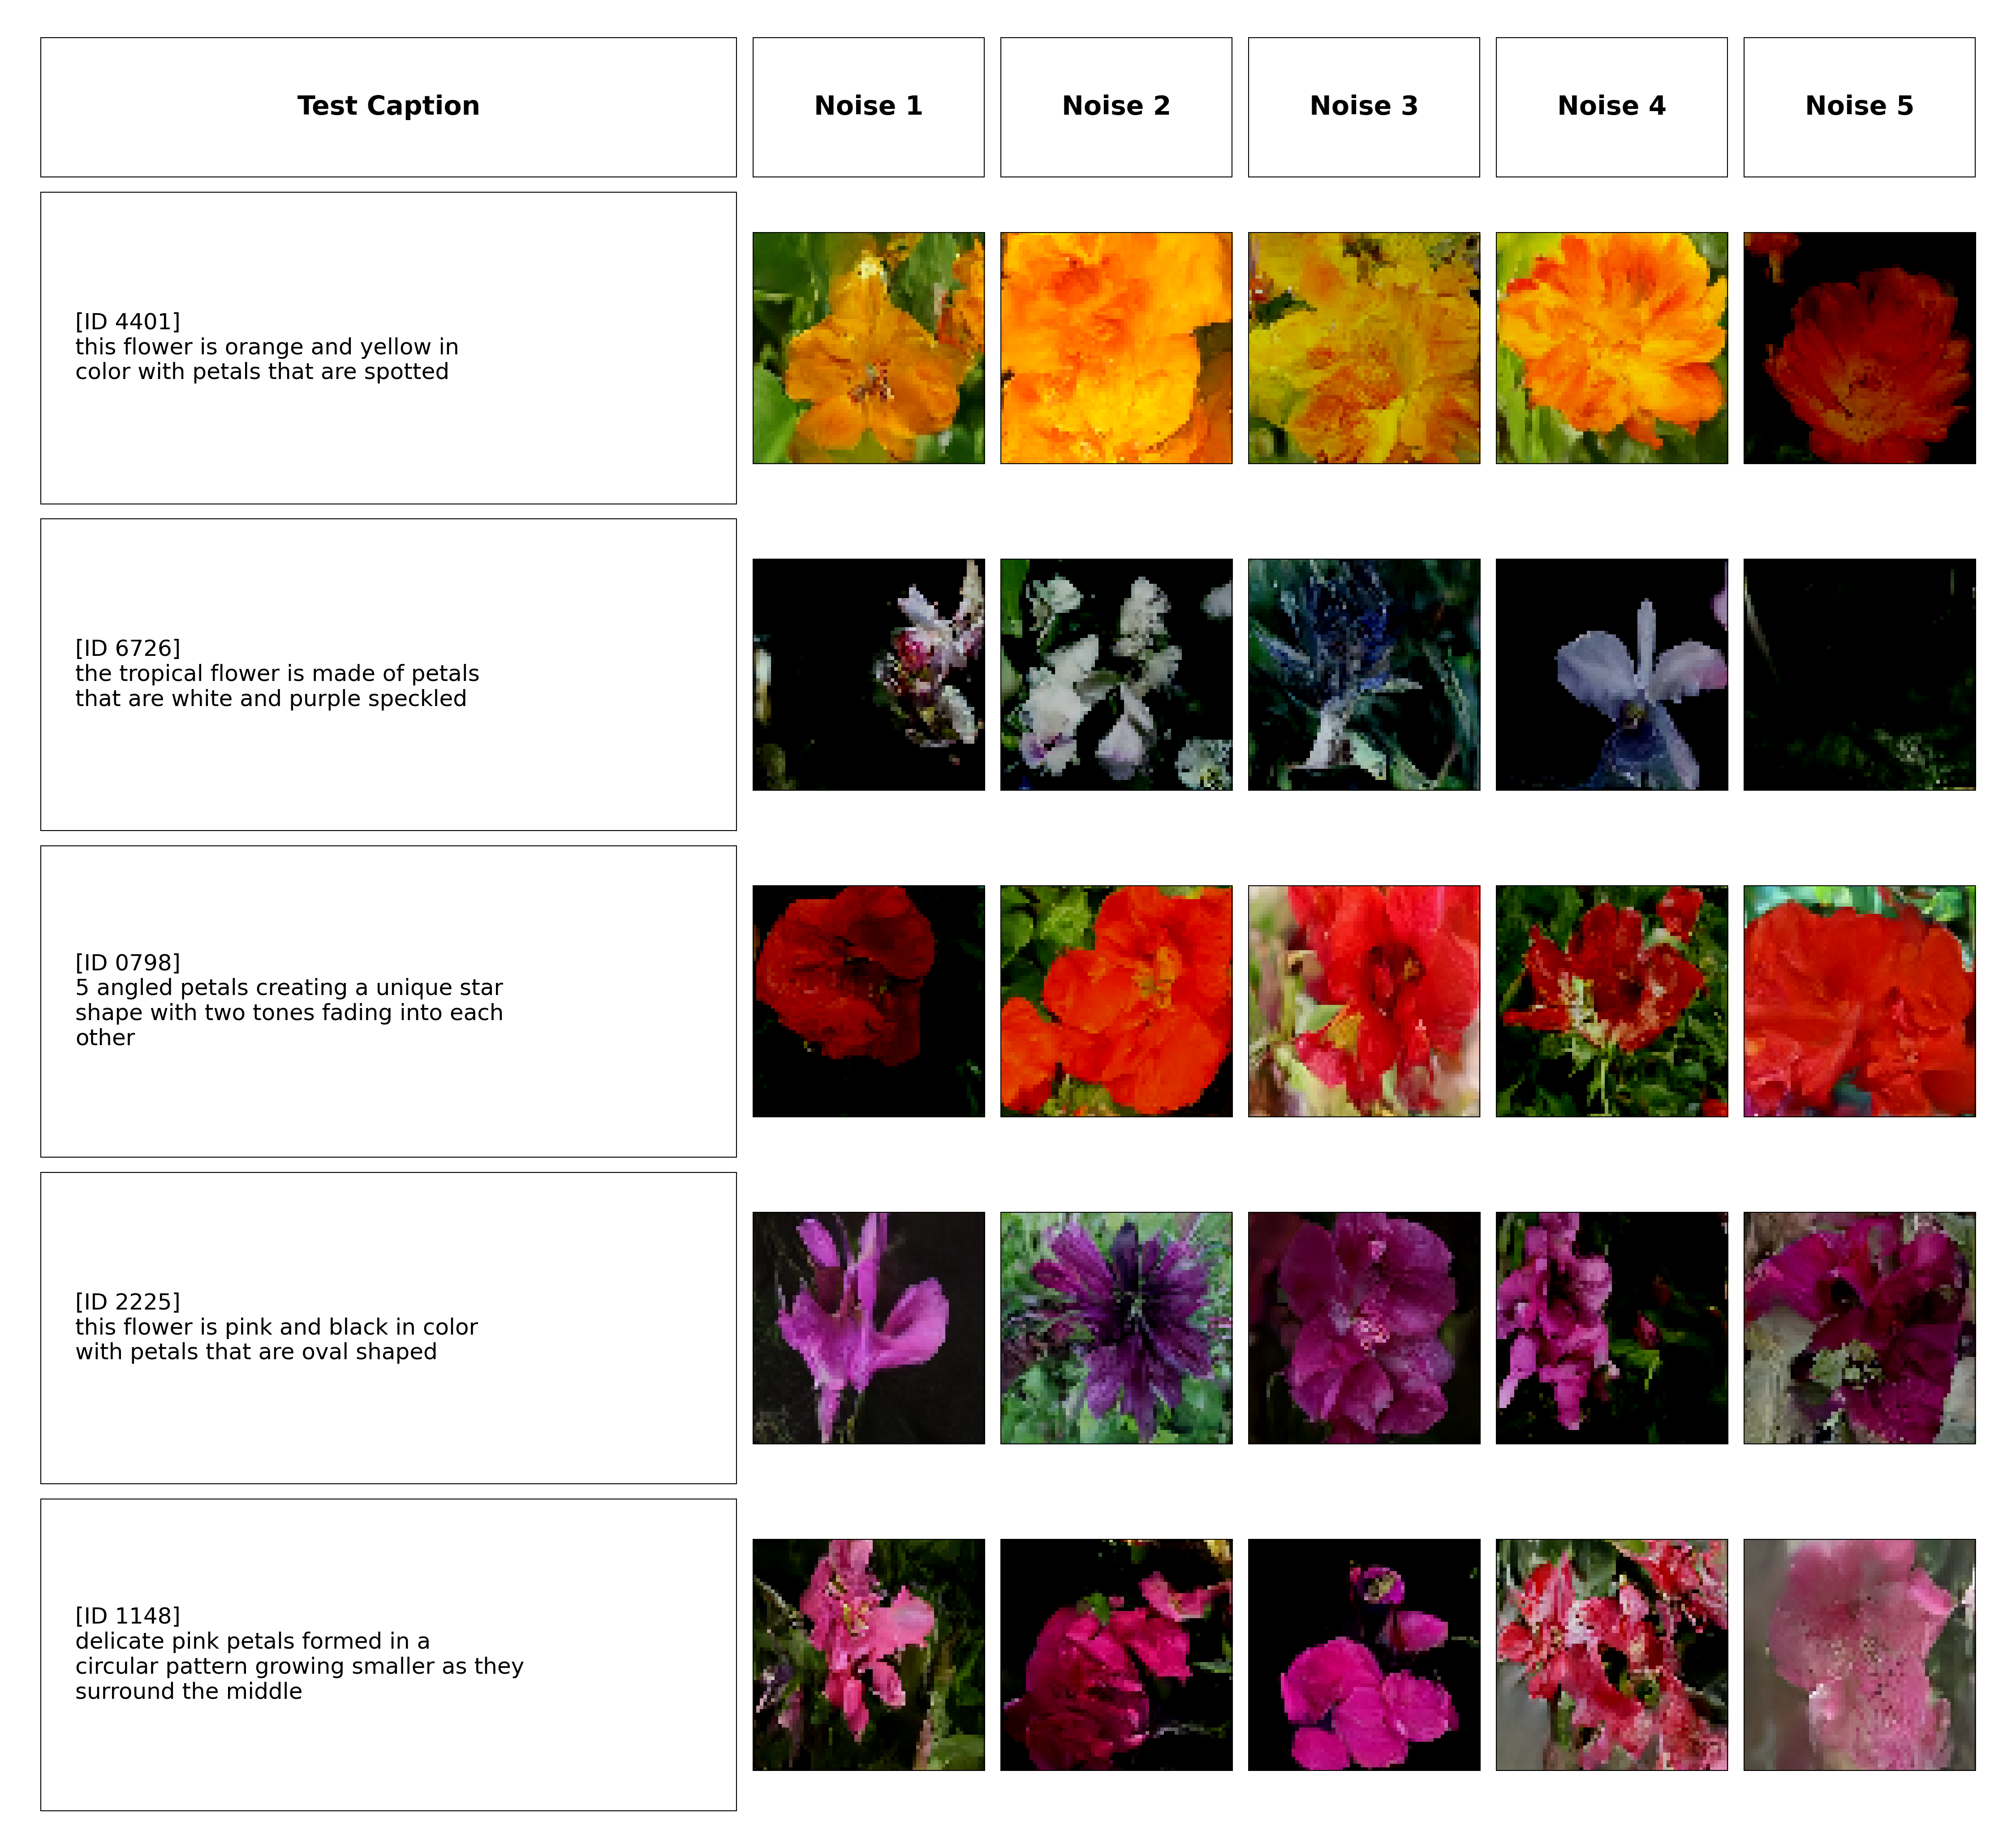

In [10]:
from IPython.display import Image
Image('./5captions_5noises_diffusion.png')

### **VI. Conclusion**
- GAN 訓練和推論速度快很多，且在色塊上更好控制，但是整體畫質上不如 Diffusion。
- Diffusion 模型在畫質上有明顯優勢，但訓練時間超長且對文字描述的控制較弱。
- 這次作業讓我們體會到訓練 GAN 是玄學，以及見證 Diffusion 畫質的強大。